# Домашнее задание 3. Анализ данных

Задание выполнил(а):

Петр Бондарев

# Часть I

Каждое задание в этой части оценивается в 0,15 баллов. Всего за выполнение этой части можно получить 2,55 балла.

In [2]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 769.8 kB/s  0:00:26m0:00:0100:01


In [23]:
!pip install requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [requests]


In [24]:
import ast
import re
from urllib.parse import urlencode

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from scipy.stats import norm

In [7]:
DIABETS = 'https://raw.githubusercontent.com/evgpat/datasets/main/pima_indians_diabetes.csv'
BABIES = 'https://raw.githubusercontent.com/evgpat/datasets/main/babies_all.txt'

Будем работать с датасетом Pima Indian Diabetes - это набор данных из Национального института диабета, болезней органов пищеварения и почек. Целью набора данных является диагностическое прогнозирование наличия диабета у пациента. Несколько ограничений были наложены на выбор этих экземпляров из большой базы данных. В частности, все пациенты здесь - женщины в возрасте от 21 года, индийского происхождения.

In [8]:
data = pd.read_csv(DIABETS)
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


Описание данных:

- __Pregnancies__ - данная единица отображает количество беременностей, единицы измерения - целые числа от 0 до N. Тип переменной - количественная, дискретная.
- __Glucose__ - данная единица отображает уровень глюкозы в крови, единицы измерения - целые числа. Тип переменной - количественная, дискретная.
- __BloodPressure__ - данная единица отображает артериальное давление, единицы измерения - миллиметры р/с, целые числа. Тип переменной - количественная, дискретная.
- __SkinThickness__ - данная единица отображает обхват трицепса в миллиметрах, целые числа. Тип переменной - количественная, дискретная.
- __Insulin__ - данная единица отображает уровень инсулина в крови, целые числа. Тип переменной - количественная, дискретная.
- __BMI__ - данная единица отображает индекс массы тела. Тип переменной - количественная, непрерывная.
- __DiabetesPedigreeFunction__ - данная единица отображает риск наследственного диабета в зависимости наличия диабета у родственников. Выражается десятичной дробью от 0 до 1. Тип переменной - количественная, непрерывная.
- __Age__ - данная единица отражает возраст в целых числах. Тип переменной - количественная, дискретная.
- __Class__ - данная единица отражает наличие диабета у субъекта, выражена 0(здоров) или 1(болен). Тип переменной - категориальная, бинарная.

## Задание 1

Как вы видите, в данных много пропусков (NaN). Любым способом посчитайте количество пропусков в каждом из столбцов.

Для тех переменных, в которых есть пропуски, выведите количество пропущенных значений в следующем формате:

**"В переменной {название переменной} {количество} пропущенных значений"**

In [9]:
missing = data.isna().sum()
for col, cnt in missing[missing > 0].items():
    print(f"В переменной {col} {cnt} пропущенных значений")

В переменной Glucose 5 пропущенных значений
В переменной BloodPressure 35 пропущенных значений
В переменной SkinThickness 227 пропущенных значений
В переменной Insulin 374 пропущенных значений
В переменной BMI 11 пропущенных значений


## Задание 2

Замените все пропуски дискретных признаков соответствующими медианами, непрерывных признаков - средними значениями.

In [10]:
discrete_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "Age",
    "Class",
]
continuous_cols = ["BMI", "DiabetesPedigreeFunction"]

data[discrete_cols] = data[discrete_cols].fillna(data[discrete_cols].median())
data[continuous_cols] = data[continuous_cols].fillna(data[continuous_cols].mean())

## Задание 3

Выведите основные статистики (минимум, максимум, среднее, дисперсию, квантили) для всех столбцов.

In [11]:
stats = data.describe().T
stats["var"] = data.var()
stats[["min", "max", "mean", "var", "25%", "50%", "75%"]]

,min,max,mean,var,25%,50%,75%
Pregnancies,0.000,17.00,3.845052,11.354056,1.00000,3.0000,6.00000
Glucose,44.000,199.00,121.656250,926.489244,99.75000,117.0000,140.25000
BloodPressure,24.000,122.00,72.386719,146.328741,64.00000,72.0000,80.00000
SkinThickness,7.000,99.00,29.108073,77.285567,25.00000,29.0000,32.00000
Insulin,14.000,846.00,140.671875,7462.033002,121.50000,125.0000,127.25000
BMI,18.200,67.10,32.457464,47.267706,27.50000,32.4000,36.60000
DiabetesPedigreeFunction,0.078,2.42,0.471876,0.109779,0.24375,0.3725,0.62625
Age,21.000,81.00,33.240885,138.303046,24.00000,29.0000,41.00000
Class,0.000,1.00,0.348958,0.227483,0.00000,0.0000,1.00000


## Задание 4

У скольких женщин строго старше 50 лет обнаружен диабет?

In [12]:
data.query("Age > 50 and Class == 1").shape[0]

38

## Задание 5

Найдите трех женщин с наибольшими числом беременностей.

In [13]:
data.nlargest(3, "Pregnancies")


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
159,17,163.0,72.0,41.0,114.0,40.9,0.817,47,1
88,15,136.0,70.0,32.0,110.0,37.1,0.153,43,1
298,14,100.0,78.0,25.0,184.0,36.6,0.412,46,1


## Задание 6

Сколько женщин возраста между 30 и 40 успело родить 3 или более детей?

In [14]:
data[(data["Age"].between(30, 40)) & (data["Pregnancies"] >= 3)].shape[0]

142

## Задание 7

Нормальным кровяным давлением будем считать давление в диапазоне [80-89]. У какого процента женщин давление нормальное?

In [16]:
print(f"{data['BloodPressure'].between(80, 89).mean() * 100:.2f}")

18.88


## Задание 8

Считается, что BMI >= 30 - это признак ожирения.
У скольких женщин с признаками ожирения кровяное давление выше среднего?

In [17]:
mean_bp = data["BloodPressure"].mean()
data[(data["BMI"] >= 30) & (data["BloodPressure"] > mean_bp)].shape[0]

251

## Задание 9

Сравните средние значения для признаков __Glucose,	BloodPressure,	Insulin__ среди тех, у кого обнаружен диабет, и тех, у кого его нет.

In [18]:
data.groupby("Class")["Glucose"].mean()

Class
0    110.682000
1    142.130597
Name: Glucose, dtype: float64

In [19]:
data.groupby("Class")["BloodPressure"].mean()

Class
0    70.920000
1    75.123134
Name: BloodPressure, dtype: float64

In [20]:
data.groupby("Class")["Insulin"].mean()

Class
0    127.792000
1    164.701493
Name: Insulin, dtype: float64

## Задание 10

Постройте гистограммы для любых двух количественных признаков.

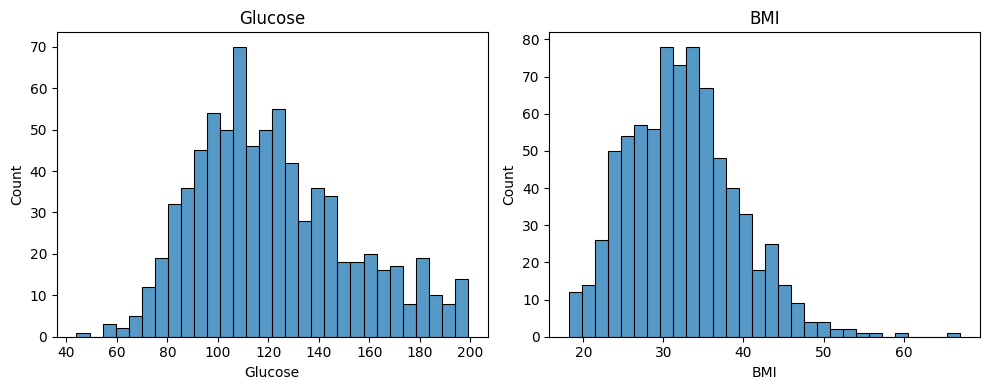

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(data["Glucose"], bins=30, ax=axes[0])
axes[0].set_title("Glucose")
sns.histplot(data["BMI"], bins=30, ax=axes[1])
axes[1].set_title("BMI")
plt.tight_layout()

## Задание 11

Постройте круговую диаграмму для признака __Class__.

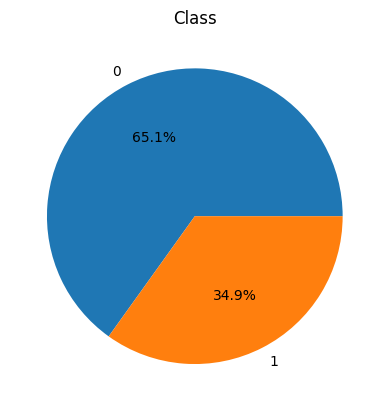

In [26]:
data["Class"].value_counts().plot.pie(autopct="%1.1f%%", ylabel="")
plt.title("Class")
plt.show()

## Задание 12

Постройте распределение для признака __BMI__ и сравните его с нормальным (напишите вывод в новой markdown-ячейке под графиками)

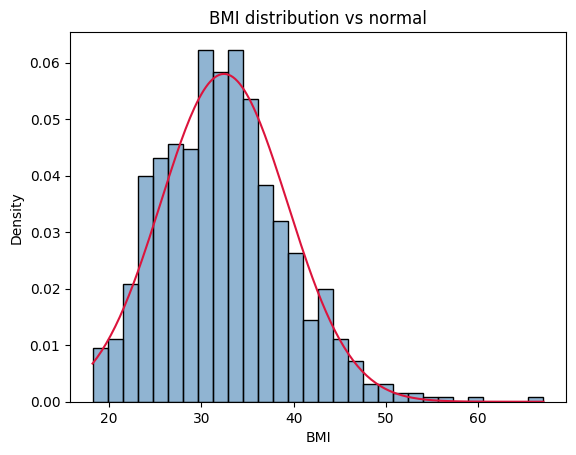

In [27]:
mu, sigma = data["BMI"].mean(), data["BMI"].std()
xs = np.linspace(data["BMI"].min(), data["BMI"].max(), 200)

sns.histplot(data["BMI"], bins=30, stat="density", color="steelblue", alpha=0.6)
plt.plot(xs, norm.pdf(xs, mu, sigma), color="crimson")
plt.title("BMI distribution vs normal")
plt.show()

Постройте нормальное распределение поверх графика.

In [35]:
print(f"{data["BMI"].skew():.2f}")

0.60


По форме распределение BMI близко к нормальному, но заметна асимметрия и правый хвост, поэтому нормальное приближение не идеальное.

## Задание 13

Постройте следующий график: процент больных диабетом в зависимости от числа беременностей.

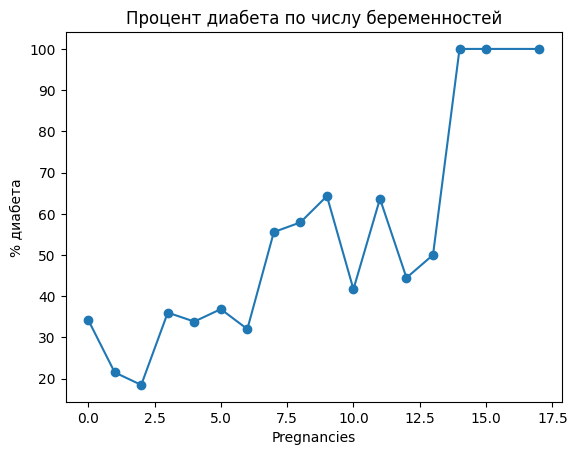

In [29]:
pct_diabetes = data.groupby("Pregnancies")["Class"].mean() * 100
plt.plot(pct_diabetes.index, pct_diabetes.values, marker="o")
plt.xlabel("Pregnancies")
plt.ylabel("% диабета")
plt.title("Процент диабета по числу беременностей")
plt.show()

## Задание 14

Добавьте новый бинарный признак:

__wasPregnant__ $\in$ {0,1} - была женщина беременна (1) или нет (0)

In [30]:
data["wasPregnant"] = (data["Pregnancies"] > 0).astype(int)
data[["Pregnancies", "wasPregnant"]].head()

,Pregnancies,wasPregnant
0,6,1
1,1,1
2,8,1
3,1,1
4,0,0


## Задание 15

Сравните процент больных диабетом среди женщин, которые были беременны и не были.

In [31]:
data.groupby("wasPregnant")["Class"].mean() * 100

wasPregnant
0    34.234234
1    35.007610
Name: Class, dtype: float64

## Задание 16

Добавьте новый категориальный признак __bodyType__ на основе столбца BMI:

__BMI Categories:__
    
Underweight = <18.5

Normal weight = 18.5–24.9

Overweight = 25–29.9

Obesity = BMI of 30 or greater

Признак должен принимать значения Underweight, Normal weight, Overweight и Obesity.

In [32]:
bins = [-np.inf, 18.5, 24.9, 29.9, np.inf]
labels = ["Underweight", "Normal weight", "Overweight", "Obesity"]

data["bodyType"] = pd.cut(data["BMI"], bins=bins, labels=labels)
data[["BMI", "bodyType"]].head()

,BMI,bodyType
0,33.6,Obesity
1,26.6,Overweight
2,23.3,Normal weight
3,28.1,Overweight
4,43.1,Obesity


## Задание 17

Будем считать "здоровыми" тех, у кого нормальный вес и кровяное давление. Какой процент "здоровых" женщин больны диабетом?

In [36]:
healthy = (data["bodyType"] == "Normal weight") & data["BloodPressure"].between(80, 89)
print(f"{(data.loc[healthy, "Class"].mean() * 100):.2f}")

10.00


# Часть II

Каждое задание в этой части оценивается в 1,15 баллов. Всего за выполнение этой части можно получить 3,45 балла.

In [38]:
babies = pd.read_csv(BABIES, index_col=0)
babies.head(10)

,name,sex,number,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
5,Margaret,F,1578,1880
6,Ida,F,1472,1880
7,Alice,F,1414,1880
8,Bertha,F,1320,1880
9,Sarah,F,1288,1880


## Задание 1

Исследуйте набор данных `babies`. Ответьте на вопросы.

1. Какие годы включает датасет

2. Какое имя в датасете находится по индексом 121?

3. Cколько всего родилось детей по имени 'Aaron' за все время?

4. Насколько больше за все время родилось мальчиков чем девочек?

5. Cколько мальчиков родилось в 2010?

6. Сколько в датасете девочек по имени John?

In [40]:
cols = {c.lower(): c for c in babies.columns}
year_col = cols.get("year")
name_col = cols.get("name")
sex_col = cols.get("sex")
count_col = (
    cols.get("num")
    or cols.get("count")
    or cols.get("births")
    or cols.get("number")
    or cols.get("n")
)

if count_col is None:
    numeric_cols = babies.select_dtypes(include="number").columns.tolist()
    count_col = next((c for c in numeric_cols if c != year_col), None)

sex_vals = set(babies[sex_col].unique())
if "M" in sex_vals:
    boys_label, girls_label = "M", "F"
elif "boy" in sex_vals:
    boys_label, girls_label = "boy", "girl"
else:
    boys_label, girls_label = "male", "female"

years = (babies[year_col].min(), babies[year_col].max())
name_121 = babies.loc[121, name_col]

print("Годы:", years)
print("Имя по индексу 121:", name_121)
print("Всего Aaron:", babies.loc[babies[name_col] == "Aaron", count_col].sum())

boys_total = babies.loc[babies[sex_col] == boys_label, count_col].sum()
girls_total = babies.loc[babies[sex_col] == girls_label, count_col].sum()
print("Мальчиков больше на:", boys_total - girls_total)

boys_2010 = babies.loc[
    (babies[year_col] == 2010) & (babies[sex_col] == boys_label), count_col
].sum()
print("Мальчиков в 2010:", boys_2010)

john_girls = babies.loc[
    (babies[sex_col] == girls_label) & (babies[name_col] == "John"), count_col
].sum()
print("Девочек по имени John:", john_girls)

Годы: (np.int64(1880), np.int64(2010))
Имя по индексу 121: 121       Ann
121      Anne
121     Josie
121      Lola
121     Hazel
        ...  
121       Eva
121     Naomi
121     Bella
121     Jenna
121    Nicole
Name: name, Length: 131, dtype: object
Всего Aaron: 527668
Мальчиков больше на: 2422447
Мальчиков в 2010: 1898382
Девочек по имени John: 21578


## Задание 2

1. Сгруппируйте набор данных babies по году и полу и сохраните результаты в два новых датафрейма: baby_girls и baby_boys.

2. Создайте фигуру matplotlib с 3 графиками один под другим.

3. Постройте линейные графики. Первый график должен показывать тренд рождаемости для девочек, второй - для мальчиков, третий объединять их все вместе (с теми же цветами, что в индивидуальных графиках). Годы - x, количество детей - y.

4. Верхняя и правая границы графиков должны быть невидимы, к каждому графику должен быть заголовок, третий график должен содержать легенду, шкалы графиков должны быть подписаны.

5. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

6. Кратко опишите тренды в ячейке markdown под графиками.

Если при группировке вы сделали год индексом, то можно обратиться к значениям этой переменной через аттрибут `.index`

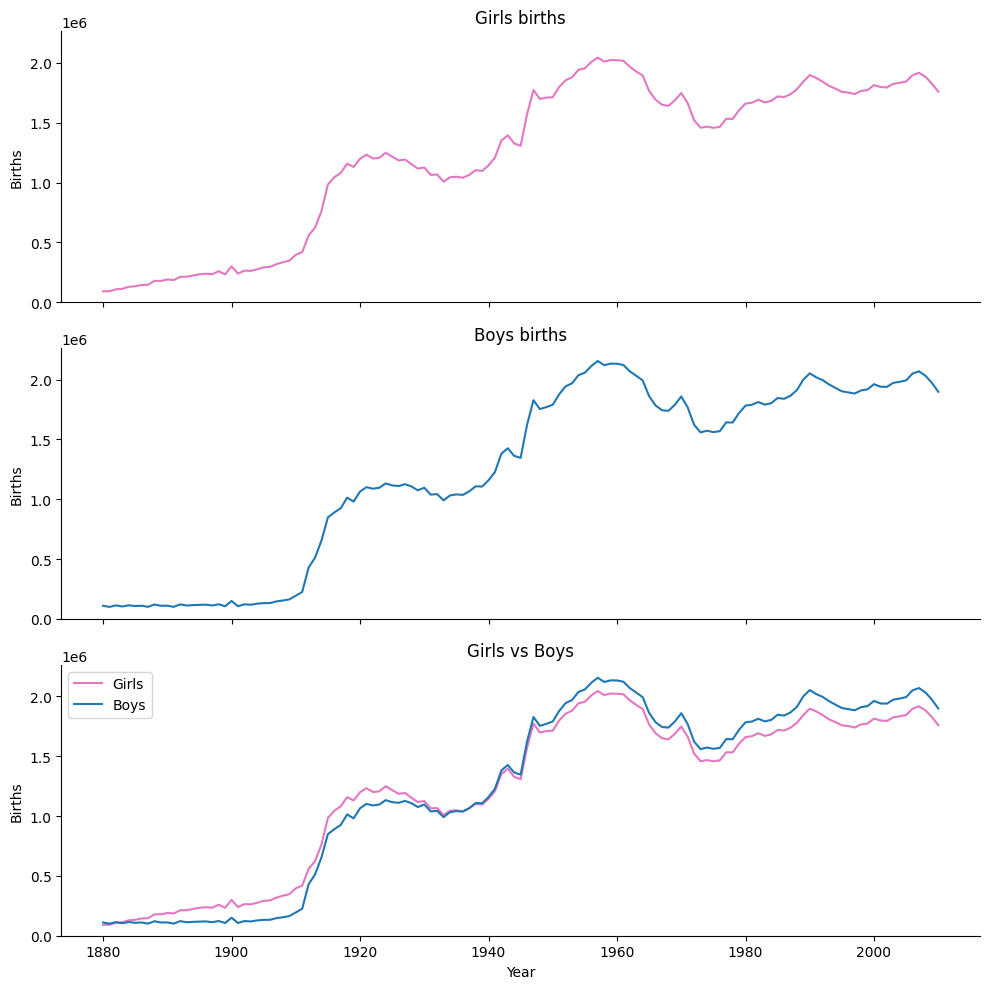

In [41]:
baby_girls = babies[babies[sex_col] == girls_label].groupby(year_col)[count_col].sum()
baby_boys = babies[babies[sex_col] == boys_label].groupby(year_col)[count_col].sum()

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(baby_girls.index, baby_girls.values, color="tab:pink")
axes[0].set_title("Girls births")
axes[1].plot(baby_boys.index, baby_boys.values, color="tab:blue")
axes[1].set_title("Boys births")

axes[2].plot(baby_girls.index, baby_girls.values, color="tab:pink", label="Girls")
axes[2].plot(baby_boys.index, baby_boys.values, color="tab:blue", label="Boys")
axes[2].set_title("Girls vs Boys")
axes[2].legend()

max_y = max(baby_girls.max(), baby_boys.max())
for ax in axes:
    ax.set_ylim(0, max_y * 1.05)
    ax.set_ylabel("Births")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[2].set_xlabel("Year")

plt.tight_layout()

Тренды для мальчиков и девочек схожи: долгий рост в первой половине века, затем спад и стабилизация; различие в уровне сохраняется почти всегда.

## Задание 3

1. Сгруппируйте нужным способом датафрейм babies и найдите 4 самых популярных имени за всю историю (2 женских и 2 мужских).

2. Для каждого найденного имени создайте новый датафрейм вида babies_alisa и сохраните в него данные, сколько детей с таким именем рождалось каждый год.

3. Создайте фигуру matplotlib с 4 горизонтальными графиками один под другим.

4. Постройте 4 линейных графика - тренд для каждого имени за все время.

5. Каждый график должен содержать легенду, один общий заголовок, шкалы графиков должны быть подписаны.

6. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

7. Опишите тренды в ячейке markdown под графиками.

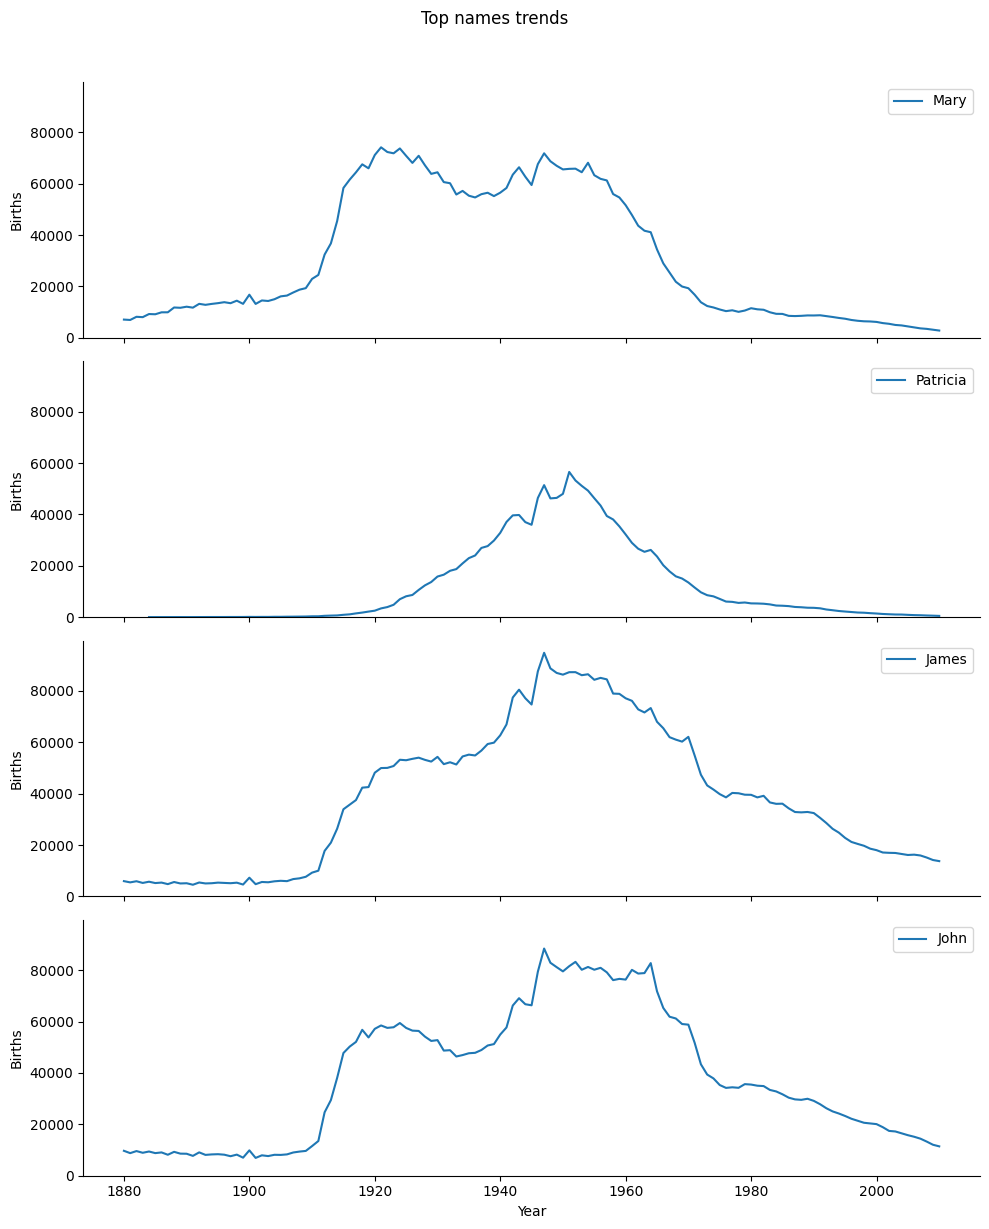

In [42]:
name_counts = babies.groupby([sex_col, name_col])[count_col].sum()
top_girls = name_counts.loc[girls_label].nlargest(2)
top_boys = name_counts.loc[boys_label].nlargest(2)

top_names = list(top_girls.index) + list(top_boys.index)

series_dict = {}
for name in top_names:
    series = babies[babies[name_col] == name].groupby(year_col)[count_col].sum()
    series_dict[name] = series
    globals()[f"babies_{name.lower()}"] = series.reset_index(name="count")

max_y = max(s.max() for s in series_dict.values())
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for ax, (name, series) in zip(axes, series_dict.items()):
    ax.plot(series.index, series.values, label=name)
    ax.legend()
    ax.set_ylabel("Births")
    ax.set_ylim(0, max_y * 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Year")
fig.suptitle("Top names trends", y=1.02)
plt.tight_layout()

Имена имеют разные пики: некоторые резко популярны в определенные годы, затем падают, другие держатся более ровно; общая тенденция совпадает с общими трендами рождаемости.

## Часть III

Каждое задание в этой части оценивается в 0,2 балла. Всего за выполнение этой части можно получить 4 балла.

Вам предлагается проанализировать датасет с Data - вакансиями.  
Скачайте его https://disk.yandex.ru/d/QUa3pCKVk48cAQ и считайте с помощью `pd.read_csv`.




In [43]:
import os

public_key = "https://disk.yandex.ru/d/QUa3pCKVk48cAQ"
api = "https://cloud-api.yandex.net/v1/disk/public/resources/download?"
download_url = requests.get(api + urlencode({"public_key": public_key})).json()["href"]

file_path = "data.csv"
if not os.path.exists(file_path):
    resp = requests.get(download_url)
    resp.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(resp.content)

df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"


1. Выведите первые 5 и последние 5 строк датасета. Примените к датасету методы `info` и `describe`. Сколько в датасете строк и столбцов?

In [44]:
display(df.head())
display(df.tail())
df.info()
df.describe(include="all")
print("Rows, cols:", df.shape)

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"


,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch..."
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[]
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[]
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra..."
1526,1526,Senior Python Developer (Data Platform),Mindbox,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p><strong>Mindbox</strong> — крупнейшая в Рос...,"['Python', 'PySpark', 'Airflow', 'Kafka', 'Del..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          1527 non-null   int64 
 1   position_name       1527 non-null   object
 2   employer_name       1527 non-null   object
 3   area                1527 non-null   object
 4   experience          1527 non-null   object
 5   schedule            1527 non-null   object
 6   employment          1527 non-null   object
 7   professional_roles  1527 non-null   object
 8   salary              220 non-null    object
 9   description         1527 non-null   object
 10  key_skills          1527 non-null   object
dtypes: int64(1), object(10)
memory usage: 131.4+ KB
Rows, cols: (1527, 11)


2. Есть ли в датасете пропуски?

In [45]:
df.isna().sum().sort_values(ascending=False).head(10)

salary                1307
Unnamed: 0               0
position_name            0
employer_name            0
area                     0
experience               0
schedule                 0
employment               0
professional_roles       0
description              0
dtype: int64

3. Есть в датасете полные дубли? Если да, удалите их (метод drop_duplicates).

In [46]:
dup_count = df.duplicated().sum()
df = df.drop_duplicates()
print("Duplicates removed:", dup_count)

Duplicates removed: 0


4. Сколько уникальных значений у переменной professional_roles?

In [47]:
df["professional_roles"].nunique()

36

5. Сколько в датасете вакансий, не требующих опыта?

In [48]:
df["experience"].fillna("").str.contains("noExperience", case=False).sum()

np.int64(0)

6. Какое среднее количество навыков в вакансии? (переменная key_skills)

In [50]:
def parse_list(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

df["key_skills_list"] = df["key_skills"].apply(parse_list)
print(f"{df["key_skills_list"].str.len().mean():.2f}")

3.87


7. Какие валюты (ключ currency в поле salary) используются для заработной платы? Создайте столбец currency.  
*Подсказка. Как вариант, можете воспользоваться функцией eval, которая исполняет код, написанный в строке. Для проверки на NaN можете использовать pd.isnull()*

In [51]:
def parse_salary(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return None

salary_parsed = df["salary"].apply(parse_salary)
df["currency"] = salary_parsed.apply(lambda d: d.get("currency") if isinstance(d, dict) else None)

df["currency"].dropna().unique()

array(['RUR', 'KZT', 'UZS', 'USD', 'EUR', 'BYR'], dtype=object)

8. Какая компания лидирует по количеству вакансий?

In [52]:
company_col = next(c for c in ["employer", "company", "employer_name"] if c in df.columns)
df[company_col].value_counts().head(1)

employer_name
СБЕР    146
Name: count, dtype: int64

9.  Какая компания лидирует по количеству вакансий с указанием заработной платы?

In [53]:
df.loc[df["salary"].notna(), company_col].value_counts().head(1)

employer_name
Aston    29
Name: count, dtype: int64

10. Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в это столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to, используйте его) **(2)**

In [54]:
def salary_to_num(d):
    if not isinstance(d, dict):
        return np.nan
    vals = [d.get("from"), d.get("to")]
    vals = [v for v in vals if isinstance(v, (int, float))]
    if len(vals) == 2:
        return sum(vals) / 2
    if len(vals) == 1:
        return vals[0]
    return np.nan

df["salary_num"] = salary_parsed.apply(salary_to_num)
df["salary_num"].head()

0    372500.0
1    800000.0
2         NaN
3         NaN
4    950000.0
Name: salary_num, dtype: float64

11. Какая средняя заработная плата среди вакансий в рублях? А медианная заработная плата?  

In [55]:
rub = df[df["currency"].isin(["RUR", "RUB"])]
print("Mean:", rub["salary_num"].mean())
print("Median:", rub["salary_num"].median())

Mean: 212395.02762430938
Median: 200000.0


12. Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python.).  Какой процент вакансий требует знания python?

In [60]:
df["is_python_requirement"] = (
    df["key_skills"].fillna("").str.contains("python", case=False)
).astype(int)

print(f"{df["is_python_requirement"].mean() * 100:.2f}")

41.45


13. Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях


In [73]:
if "is_python_requirement" not in df.columns:
    df["is_python_requirement"] = (
        df["key_skills"].fillna("").str.contains("python", case=False)
    ).astype(int)

rub = df[df["currency"].isin(["RUR", "RUB"])].copy()

group_cols = ["experience", "schedule", "employment", "is_python_requirement"]

base = df.groupby(group_cols).agg(
    vacancies=("salary_num", "size"),
    companies=(company_col, "nunique"),
)

salary_rub_mean = rub.groupby(group_cols)["salary_num"].mean()
base.join(salary_rub_mean.rename("salary_rub_mean"))

vacancies  \
experience         schedule         employment          is_python_requirement              
Более 6 лет        Гибкий график    Полная занятость    0                              4   
                                    Частичная занятость 0                              1   
                   Полный день      Полная занятость    0                             49   
                                                        1                             10   
                   Удаленная работа Полная занятость    0                             11   
                                                        1                             12   
Нет опыта          Гибкий график    Полная занятость    1                              2   
                                    Стажировка          1                              3   
                   Полный день      Полная занятость    0                             26   
                                                        1                             55   
                                    Стажировка          0                              7   
                                                        1                              9   
                   Удаленная работа Полная занятость    0                              2   
                                                        1                              1   
                                    Стажировка          0                              2   
                                                        1                             29   
От 1 года до 3 лет Вахтовый метод   Полная занятость    0                              1   
                   Гибкий график    Полная занятость    0                              6   
                                                        1                             18   
                                    Стажировка          0                              1   
                                    Частичная занятость 1                              2   
                   Полный день      Полная занятость    0                            292   
                                                        1                            156   
                   Сменный график   Полная занятость    0                              2   
                                                        1                              1   
                                    Частичная занятость 0                              1   
                   Удаленная работа Полная занятость    0                             51   
                                                        1                             46   
                                    Частичная занятость 0                              1   
                                                        1                              2   
От 3 до 6 лет      Гибкий график    Полная занятость    0                              9   
                                                        1                              7   
                                    Проектная работа    0                              1   
                   Полный день      Полная занятость    0                            320   
                                                        1                            173   
                                    Проектная работа    1                              1   
                   Удаленная работа Полная занятость    0                            106   
                                                        1                            104   
                                    Частичная занятость 0                              1   
                                                        1                              2   

                                                                               companies  \
experience         schedule         employment          is_python_requirement              
Более 6 лет        Гибкий граф

14. Создайте столбец count_skills. В нём должна быть длина списка, который находит в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]' Подумайте, как превратить её в список и посчитать его длину.  

In [63]:
df["count_skills"] = df["key_skills_list"].str.len()
df["count_skills"].describe()

count    1527.000000
mean        3.874918
std         4.242108
min         0.000000
25%         0.000000
50%         3.000000
75%         6.000000
max        25.000000
Name: count_skills, dtype: float64

15. Создайте столбец len_descr, в котором должна быть длина описания (description) в символах без учета html тегов ("<...>"). Напишите для этого функцию get_len_descr.  Можете использовать регулярные выражения.
То есть, ваш код может выглядеть, например, так:

In [64]:
def get_len_descr(descr):
    if pd.isna(descr):
        return 0
    clean_descr = re.sub(r"<[^>]+>", "", descr)
    return len(clean_descr)

df["len_descr"] = df["description"].apply(get_len_descr)
df["len_descr"].describe()

count    1527.000000
mean     2093.896529
std       808.497000
min       335.000000
25%      1520.000000
50%      1976.000000
75%      2589.000000
max      5378.000000
Name: len_descr, dtype: float64

16. Постройте таблицу корреляций с тремя переменными: salary_num, len_descr, count_skills.  

In [65]:
corr_tbl = df[["salary_num", "len_descr", "count_skills"]].corr()
corr_tbl

,salary_num,len_descr,count_skills
salary_num,1.000000,0.001213,-0.011834
len_descr,0.001213,1.000000,0.126813
count_skills,-0.011834,0.126813,1.000000


17. Постройте тепловую карту из таблицы из предыдущего пункта.

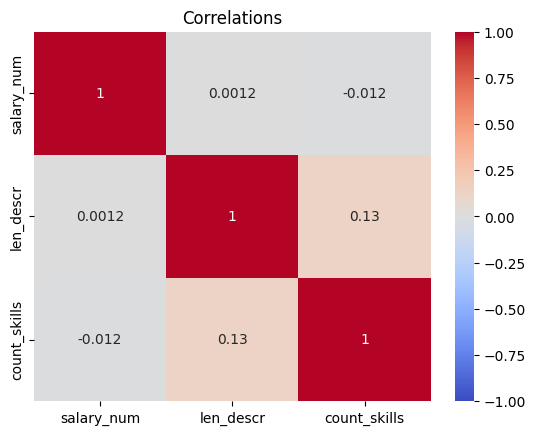

In [66]:
sns.heatmap(corr_tbl, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlations")
plt.show()

18. Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов.

In [67]:
def extract_skill_names(items):
    names = []
    for item in items:
        if isinstance(item, dict) and "name" in item:
            names.append(item["name"])
        elif isinstance(item, str):
            names.append(item)
    return names

skills = df["key_skills_list"].apply(extract_skill_names).explode().dropna()
skills.value_counts().head(10)

key_skills_list
Python                   633
SQL                      574
ETL                      154
Big Data                 146
Hadoop                   118
PostgreSQL               113
DWH                      111
Clickhouse               102
Английский язык           93
Математический анализ     90
Name: count, dtype: int64

19. Постройте гистограмму распределения зарплаты среди вакансий в рублях.  

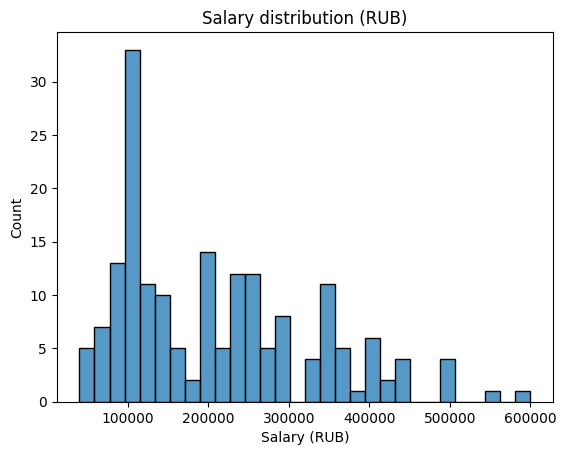

In [68]:
sns.histplot(rub["salary_num"].dropna(), bins=30)
plt.xlabel("Salary (RUB)")
plt.title("Salary distribution (RUB)")
plt.show()

20. Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience

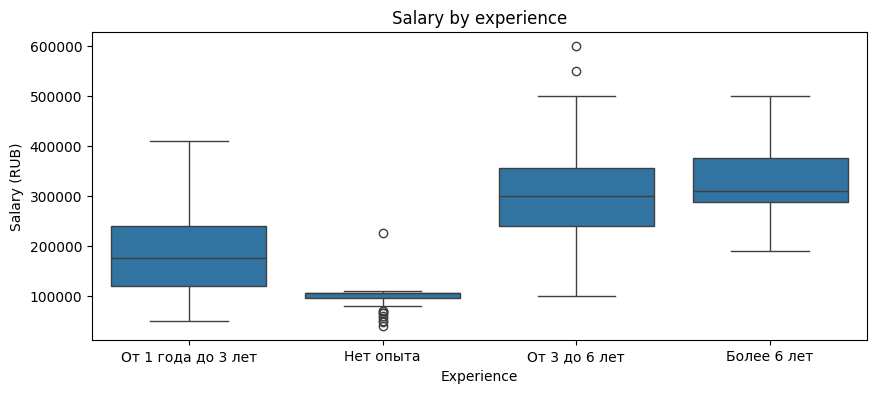

In [69]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=rub, x="experience", y="salary_num")
plt.xlabel("Experience")
plt.ylabel("Salary (RUB)")
plt.title("Salary by experience")
plt.show()